In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import nibabel as nib
import numpy as np
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from TransAttUnet import UNet_Attention_Transformer_Multiscale

残差スケール接続したんだっけ

zipファイルの解凍(やらなくてよい)

In [ ]:
import zipfile
import os

# アップロードしたzipファイル名に合わせて書き換えてください
zip_file_path = '/workspace/NSCLC_NIfTI2/imagesTr/LUNG1-301-422.nii.zip' 
# 解凍先のフォルダ
extract_dir = '/workspace/NSCLC_NIfTI2/imagesTr'

if os.path.exists(zip_file_path):
    print(f"{zip_file_path} を解凍中...")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"解凍が完了しました！場所: {extract_dir}")
else:
    print(f"エラー: {zip_file_path} が見つかりません。アップロードを確認してください。")

/workspace/NSCLC_NIfTI2/imagesTr/LUNG1-301-422.nii.zip を解凍中...
解凍が完了しました！場所: /workspace/NSCLC_NIfTI2/imagesTr


In [4]:
import os
print(os.getcwd())        # 現在の場所を表示
print(os.listdir('.'))

/workspace/TransAttUnet/model
['__pycache__', 'unet_parts_att_transformer.py', 'TransAttUnet.py', 'train_nsclc.py', 'nsclc.ipynb', 'unet_parts_att_multiscale.py', 'unet_parts.py']


In [ ]:
class NSCLCNiftiDataset(Dataset):
    def __init__(self, root_dir, file_list, target_size=(512, 512)):
        self.img_dir = os.path.join(root_dir, 'imagesTr')
        self.mask_dir = os.path.join(root_dir, 'labelsTr')
        self.file_names = file_list
        self.target_size = target_size
    
    def __len__(self):
        return len(self.file_names)
    
    def __getitem__(self, idx):
        file_id = self.file_names[idx]
        # NIfTI読み込み
        img_path = os.path.join(self.img_dir, self.file_names[idx])
        mask_path = os.path.join(self.mask_dir, self.file_names[idx])

        img_nii = nib.load(img_path).get_fdata()
        mask_nii = nib.load(mask_path).get_fdata()

        #print(f"ファイル: {file_id} / マスクの最大値: {mask_nii.max()}") # これが 0 だったら、その画像には腫瘍が映っていません
        #print(f"DEBUG: img_niiの形: {img_nii.shape}")
        #print(f"DEBUG: mask_niiの形: {mask_nii.shape}")

        # 3Dから2Dスライス(腫瘍がいちばん大きいスライスとる)
        # 配列の中で最大値となってる要素のうち先頭のインデックスを返す(argmax)
        mask_slice_sums = np.sum(mask_nii, axis=(0, 1))

        max_mask_idx = np.argmax(mask_slice_sums)

        #print(f"選んだスライス番号: {max_mask_idx}")
        #print(f"そのスライスの白さ合計: {mask_slice_sums[max_mask_idx]}")

        # 画像とlabelのshapeが合わないから、画像とラベルの枚数比の計算
        z_ratio = img_nii.shape[2] / mask_nii.shape[2]
        # 対応するインデックスを割り出す
        max_img_idx = int(max_mask_idx * z_ratio)
        # 範囲外ガード?
        max_img_idx = min(max_img_idx, img_nii.shape[2] - 1)

        img_slice = img_nii[:, :, max_img_idx]
        mask_slice = mask_nii[:, :, max_mask_idx]

        # CT値の正規化(?わからん -1000~400程度にクリップ)
        # 肺の微細な構造を鮮明に観察するための肺野条件らしい
        img_slice = np.clip(img_slice, -1000, 400)
        #0-1の正規化
        img_slice = (img_slice + 1000) / 1400

        # リサイズとテンソル化
        img_tensor = torch.from_numpy(img_slice).float().unsqueeze(0) # [1, H, W]
        mask_tensor = torch.from_numpy(mask_slice).float().unsqueeze(0)

        img_tensor = F.interpolate(img_tensor.unsqueeze(0), size=self.target_size, mode='bilinear', align_corners=False).squeeze(0)
        mask_tensor = F.interpolate(mask_tensor.unsqueeze(0), size=self.target_size, mode='nearest').squeeze(0)

        return img_tensor, mask_tensor, file_id

if __name__ == '__main__':
    root_dir = '/workspace/NSCLC_NIfTI2'

    images_dir = '/workspace/NSCLC_NIfTI2/imagesTr'
    labels_dir = '/workspace/NSCLC_NIfTI2/labelsTr'

    # 全てのファイル名を取得
    all_images = sorted([f for f in os.listdir(images_dir) if f.endswith('.nii.gz')])

    # ラベル側
    valid_files = [f for f in all_images if os.path.exists(os.path.join(labels_dir, f))]

    print(f"画像総数: {len(all_images)}")
    print(f"ラベルがある有効な数: {len(valid_files)}")
    print(f"除外されたファイル: {set(all_images) - set(valid_files)}")

    # train 8  test 2で分割
    train_files, test_files = train_test_split(valid_files, test_size=0.2, random_state=42)

    print(f"--- データ分割完了 ---")
    print(f"学習用 (train): {len(train_files)} 症例")
    print(f"テスト用 (test): {len(test_files)} 症例")

画像総数: 422
ラベルがある有効な数: 421
除外されたファイル: {'LUNG1-128.nii.gz'}
--- データ分割完了 ---
学習用 (train): 336 症例
テスト用 (test): 85 症例


In [10]:
# 学習設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_dataset = NSCLCNiftiDataset(root_dir=root_dir, file_list=train_files)
test_dataset = NSCLCNiftiDataset(root_dir=root_dir, file_list=test_files)

train_loader = DataLoader(train_dataset, batch_size=6, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=6, shuffle=False)

model = UNet_Attention_Transformer_Multiscale(n_channels=1, n_classes=1).to(device)
#最適化アルゴリズム
optimizer = optim.SGD(model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-4)
# 損失関数
criterion = nn.BCEWithLogitsLoss()

num_epochs = 50

train_loss_history = []
val_loss_history = []

下のは動かさなくていい(確認用)

In [4]:
import nibabel as nib
import os

images_dir = '/workspace/NSCLC_NIfTI/NSCLC_NIfTI/labelsTr'
all_files = sorted([f for f in os.listdir(images_dir) if f.endswith('.nii.gz')])

broken_files = []
for f in all_files:
    try:
        img = nib.load(os.path.join(images_dir, f))
        _ = img.get_fdata() # 実際にデータを読み込んでチェック
    except Exception as e:
        print(f"壊れたファイルを発見: {f} ({e})")
        broken_files.append(f)

print(f"計 {len(broken_files)} 件の壊れたファイルが見つかりました。")

KeyboardInterrupt: 

In [16]:
import os
sample_file = '/workspace/NSCLC_NIfTI2/imagesTr/LUNG1-422.nii.gz'
if os.path.exists(sample_file):
    size = os.path.getsize(sample_file)
    print(f"ファイルサイズ: {size / (1024*1024):.2f} MB")

ファイルサイズ: 28.54 MB


In [5]:
import os
import nibabel as nib
import numpy as np

images_dir = '/workspace/NSCLC_NIfTI2/imagesTr'
labels_dir = '/workspace/NSCLC_NIfTI2/labelsTr'
corrupted_files = []
mismatched_files = []

print("整合性チェックを開始します...")

# imagesTrにあるファイルを基準にチェック
for filename in sorted(os.listdir(images_dir)):
    if not filename.endswith('.nii.gz'):
        continue
        
    img_path = os.path.join(images_dir, filename)
    label_path = os.path.join(labels_dir, filename)
    
    try:
        # 1. ファイルが正常に開けるか（破損チェック）
        img = nib.load(img_path)
        img_data = img.get_fdata()
        
        # ラベルがあるか確認
        if not os.path.exists(label_path):
            print(f"  [欠損] ラベルがありません: {filename}")
            continue
            
        mask = nib.load(label_path)
        mask_data = mask.get_fdata()
        
        # 2. サイズ（スライス数）が一致しているか
        if img_data.shape != mask_data.shape:
            mismatched_files.append((filename, img_data.shape, mask_data.shape))
            
    except Exception as e:
        # 読み込み中にエラーが出たら「破損」とみなす
        print(f"  [破損] 読み込み失敗: {filename} - {str(e)}")
        corrupted_files.append(filename)

print("\n--- チェック完了 ---")
print(f"スキャン総数: {len(os.listdir(images_dir))}")
print(f"読み込み失敗（破損）: {len(corrupted_files)} 件")
print(f"サイズ不一致: {len(mismatched_files)} 件")

# 不一致があった場合、具体的に表示
if mismatched_files:
    print("\n【詳細: サイズ不一致の例】")
    for name, img_shape, mask_shape in mismatched_files[:5]: # 最初の5件だけ表示
        print(f"{name}: 画像{img_shape} vs ラベル{mask_shape}")

整合性チェックを開始します...


KeyboardInterrupt: 

ここから

In [ ]:
print("学習を開始...")
for epoch in range(num_epochs):
    # 学習
    model.train()
    train_loss = 0.0
    for images, masks, file_ids in train_loader:
        images, masks = images.to(device), masks.to(device)

        # 予測と計算
        outputs = model(images)
        loss = criterion(outputs, masks)

        # 重みの更新
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss /len(train_loader)

        # 検証(テストデータでの評価)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, masks, file_ids in test_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            v_loss = criterion(outputs, masks)
            val_loss += v_loss.item()

    avg_val_loss = val_loss / len(test_loader)

    train_loss_history.append(avg_train_loss)
    val_loss_history.append(avg_val_loss)

    # 進捗を表示
    print(f"Epoch [{epoch+1}/{num_epochs}] Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # モデルの保存
    os.makedirs('checkpoints', exist_ok=True)

    # 10エポックごとに重みを保存
    if (epoch + 1) % 10 == 0:
        save_path = f"checkpoints/model_epoch_{epoch+1}.pth"
        torch.save(model.state_dict(), save_path)
        print(f"--- モデルを保存しました: {save_path}")

print("すべての学習が完了しました。")

学習を開始...
Epoch [1/50] Train Loss: 0.5902, Val Loss: 0.5990
Epoch [2/50] Train Loss: 0.4354, Val Loss: 0.3904
Epoch [3/50] Train Loss: 0.3469, Val Loss: 0.3203
Epoch [4/50] Train Loss: 0.2919, Val Loss: 0.2796
Epoch [5/50] Train Loss: 0.2544, Val Loss: 0.2486
Epoch [6/50] Train Loss: 0.2276, Val Loss: 0.2252
Epoch [7/50] Train Loss: 0.2067, Val Loss: 0.2039
Epoch [8/50] Train Loss: 0.1908, Val Loss: 0.1909
Epoch [9/50] Train Loss: 0.1779, Val Loss: 0.1803
Epoch [10/50] Train Loss: 0.1666, Val Loss: 0.1731
--- モデルを保存しました: checkpoints/model_epoch_10.pth
Epoch [11/50] Train Loss: 0.1586, Val Loss: 0.1628
Epoch [12/50] Train Loss: 0.1516, Val Loss: 0.1554
Epoch [13/50] Train Loss: 0.1454, Val Loss: 0.1548
Epoch [14/50] Train Loss: 0.1398, Val Loss: 0.1469
Epoch [15/50] Train Loss: 0.1355, Val Loss: 0.1472
Epoch [16/50] Train Loss: 0.1307, Val Loss: 0.1433
Epoch [17/50] Train Loss: 0.1267, Val Loss: 0.1399
Epoch [18/50] Train Loss: 0.1237, Val Loss: 0.1346
Epoch [19/50] Train Loss: 0.1216, V

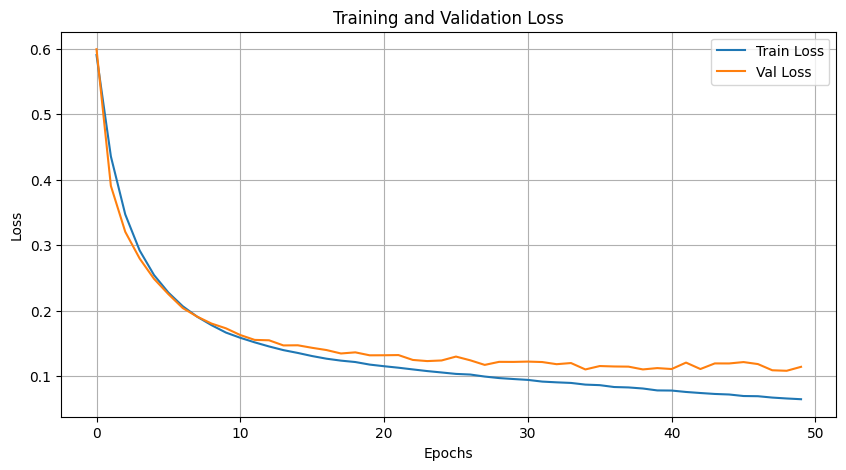

In [12]:
# グラフの描画
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

予測と可視化

足りない部品: []
余計な部品: []
予測値の最小: 0.0014
予測値の最大: 0.9980
予測値の平均: 0.0978
入力画像の形: torch.Size([6, 1, 512, 512])
DEBUG: masks のバッチ内最大値: 1.0


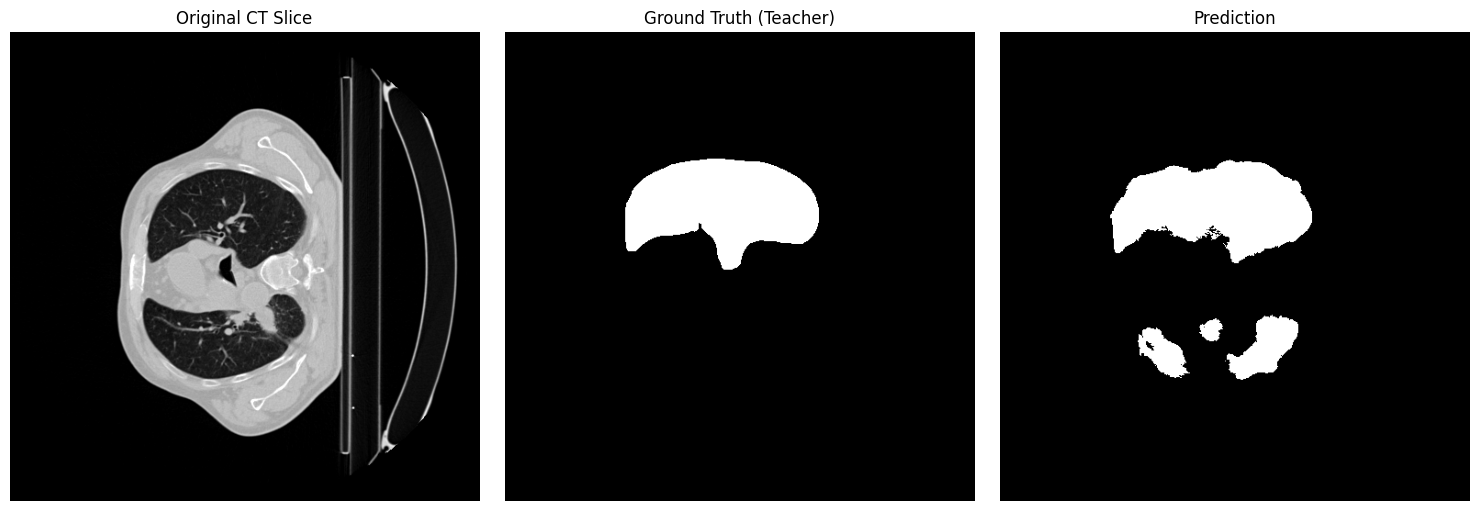

In [13]:
model.to(device)

# 保存した重み
model_path = '/workspace/TransAttUnet/model/checkpoints/model_epoch_50.pth'
missing_keys, unexpected_keys = model.load_state_dict(torch.load(model_path), strict=False)
print(f"足りない部品: {missing_keys}")
print(f"余計な部品: {unexpected_keys}")
# 評価
model.eval()

# テストデータから1つ取り出して予測
with torch.no_grad():
    # test\loaderから最初の1バッチを取得
    for images, masks in test_loader:
        images = images.to(device)

        #images = torch.flip(images, dims=[3])
        #masks = torch.flip(masks, dims=[3])

        # 予測
        outputs = model(images)

        # 2. もし outputs.shape[1] が 2 以上なら、チャンネルを切り替えてみる
        if outputs.shape[1] > 1:
             # チャンネル1 (腫瘍クラス) を取得
             preds = torch.softmax(outputs, dim=1)[:, 1, :, :] 
        else:
             # チャンネル1なら今まで通り Sigmoid
             preds = torch.sigmoid(outputs)

        preds = torch.sigmoid(outputs)

        print(f"予測値の最小: {preds.min().item():.4f}")
        print(f"予測値の最大: {preds.max().item():.4f}")
        print(f"予測値の平均: {preds.mean().item():.4f}")

        print(f"入力画像の形: {images.shape}")

        # 0.5をしきい値として腫瘍か背景か判定
        # 0.5という絶対的な基準で切る。これが白くなれば「合格」
        preds_binary = (preds > 0.5).float()
        #preds_binary = (preds > (preds.max() * 0.5)).float()

        img_show = images[0, 0].cpu().numpy()
        mask_show = masks[0, 0].cpu().numpy()
        pred_show = preds_binary[0, 0].cpu().numpy()
        print(f"DEBUG: masks のバッチ内最大値: {masks.max().item()}")

        break

# 可視化
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original CT Slice")
plt.imshow(img_show, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Ground Truth (Teacher)")
# 重ねて表示
plt.imshow(mask_show, vmin=0, vmax=1, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
# 予測
# 予測だけを見る
plt.title("Prediction")
plt.imshow(pred_show, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.tight_layout()
plt.show()


### 予測と可視化
10人分の画像を表示
- 患者ID
- CT Slice
- GT
- Prediction

In [ ]:
def visualize_10_patients(model, test_loader, device, save_path="results_10_patients.png"):
    model.eval()
    patients_count = 0
    max_patients = 10

    # グラフサイズ(10行3列)
    fig, axes = plt.subplots(max_patients, 3, figsize=(15, 5 * max_patients))

    with torch.no_grad():
        for i, data in enumerate(test_loader):
            if patients_count >= max_patients:
                break

            images, masks, file_ids = data

            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)

            # バッチの1枚目を取得
            img = images[0, 0].cpu().numpy()
            gt = masks[0, 0].cpu().numpy()
            pred = preds[0, 0].cpu().numpy()
            p_id = file_ids[0] # 患者名

            # 描画
            # CT画像
            axes[patients_count, 0].imshow(img, cmap='gray')
            axes[patients_count, 0].set_title(f"Patient: {p_id} (CT)")
            axes[patients_count, 0].axis('off')

            # Ground Truth
            axes[patients_count, 1].imshow(gt, cmap='gray')
            axes[patients_count, 1].set_title("Ground Truth")
            axes[patients_count, 1].axis('off')

            # Prediction (Overlay)
            axes[patients_count, 2].imshow(img, cmap='gray')
            axes[patients_count, 2].imshow(pred, cmap='jet', alpha=0.4)
            axes[patients_count, 2].set_title(f"Prediction (Max: {pred.max():.4f})")
            axes[patients_count, 2].axis('off')
            
            patients_count += 1
        
        plt.tight_layout()
        plt.savefig(save_path)
        print(f"Saved visualization to {save_path}")

            
   

In [ ]:
# 関数の呼び出し
visualize_10_patients(model, test_loader, device, save_path="final_analysis_10_patients.png")

# グラフ表示
plt.show()

デバック用

In [26]:
# 1. Datasetのインスタンスを作成（今の設定に合わせて）
check_dataset = NSCLCNiftiDataset(root_dir, train_files)

# 2. 直接 __getitem__ を呼び出す（ここで print が出るはず！）
img, mask = check_dataset[0] 

# 3. ついでに外側でも値を確認
print("--- データの最終確認 ---")
print(f"画像形状: {img.shape}")
print(f"マスク形状: {mask.shape}")
print(f"マスクの最大値 (外側): {mask.max()}")

ファイル: LUNG1-133.nii.gz / マスクの最大値: 1.0
DEBUG: img_niiの形: (512, 512, 184)
DEBUG: mask_niiの形: (512, 512, 736)
選んだスライス番号: 412
そのスライスの白さ合計: 18164.0
--- データの最終確認 ---
画像形状: torch.Size([1, 512, 512])
マスク形状: torch.Size([1, 512, 512])
マスクの最大値 (外側): 1.0
